# 251. Moving a DisProt function label onto a human disordered region

DisProt records stretches of proteins that experiments showed to be disordered, and what
each stretch does: a flexible linker, a phosphorylation site display, a binding surface
that folds only on its partner. This notebook asks whether a search tool can take that
label from a protein in another organism and put it on the right stretch of a human
protein.

A **call** is one region a tool reports between a human protein and a target protein. It
carries a DisProt label when it covers at least half of a DisProt functional region on the
target, the transfer rule every region benchmark in this project uses. The call's human
interval then says where the function sits on the human protein, and it is compared with
the human protein's own DisProt region. A call **lands** when at least 80% of it lies
inside the human region and it covers at least 30% of the region (notebook 244's rule).
IoU is the overlap between the call and the region divided by their union.

This is the companion to notebook 250, which does the same for short ELM motifs. The
setup is the same: the same kmerseek arms (every alphabet at every k of the midi-plus
band, low-complexity mask on and off), ungapped kmerseek regions, and the same comparison
tools with their filters opened. Every tool is cut to its best 1_000 target proteins per
human protein before any label is moved.

| | |
|---|---|
| queries | human proteins with a DisProt functional region backed by experiment, on a stretch shown disordered by experiment (`scripts/fetch_disprot.py`) |
| targets | the nine QfO proteomes, and one pool of every non-human DisProt protein with such a region |
| label rules | the target region has the **same** DisProt function term, or **any** function term |
| split | human proteins by HGNC gene group into a half that picks the kmerseek arm and a half that is reported; and, separately, function terms into the same two halves |
| kmerseek ranking | mean k-mer rarity (`region_mean_idf`) for regions under 30 aa, the E-value for 30 aa and longer |

## Which targets, and which label rule: what each one can and cannot say

A label can only come from a target protein DisProt itself annotated, and DisProt
annotates few proteins outside human, mouse, yeast and arabidopsis. That forces a choice
of target, and both choices are run.

| | the nine QfO proteomes | all non-human DisProt proteins, pooled |
|---|---|---|
| what a hit competes with | every protein of the organism, so a wrong hit is as easy to make as in real use | only other DisProt proteins, about 700, so a wrong hit is rarer than in real use |
| where a label can come from | the few proteins DisProt annotated in that organism: none in ciona, 4 in zebrafish | every annotated organism, viruses and bacteria included |
| can results be read by divergence from human | yes, one organism per target | no, the donors are mixed; the notebook reports the donor organism per case |
| main risk | most cells are empty, so a species-level number rests on a handful of regions | the small target set makes every tool look better than it would against a proteome |

| | same function term | any function term |
|---|---|---|
| what a landed call means | the function was moved: flexible linker onto flexible linker | the tool found a functional disordered region at the right place, whatever its function |
| main risk | terms are uneven (protein binding is 365 of the 1_177 human regions, 31%), so a few terms carry the number | a call from an unrelated functional region can land by position alone, which is what the placement control below measures |

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

sys.path.insert(0, str(Path.cwd()))
import disprot_region_utils as du
import hero_example_utils as he
import mhc_region_utils as mu

plt.rcParams.update({"figure.dpi": 110, "savefig.bbox": "tight", "font.size": 9.5})
pl.Config.set_tbl_rows(60)
pl.Config.set_tbl_cols(30)
pl.Config.set_tbl_width_chars(230)
pl.Config.set_fmt_str_lengths(60)

FIG = Path("../figures")
TAB = Path("../tables")
TAB.mkdir(exist_ok=True)
KEY = du.REGION_KEY
print(f"landing tables: {du.LANDING_DIR}")

landing tables: /Users/olga/data/disprot-region-transfer/dryrun/results/landing_disprot


## 1. The regions, and why a structure tool has little to align

Three numbers per human region: its length; AlphaFold's confidence over its residues
(pLDDT, 0-100; under 70 the backbone should not be trusted, under 50 there is usually no
structure at all); and the share of its residues metapredict 3.0.1 calls disordered
(score >= 0.5). The regions were chosen for experimental disorder, so low pLDDT and high
disorder are expected by construction. What matters for this benchmark is how complete
that is: a region with a confident structure is one a structure tool can align.

In [2]:
S = du.fetch_summary()
print(f"DisProt {S['release']}: {S['n_proteins']} proteins, {S['n_function_regions']} functional-region rows")
print(f"  dropped, evidence not experimental: {S['n_dropped_evidence']}")
print(f"  dropped, no experimentally shown disorder under it: {S['n_dropped_no_disorder']}")
print(f"  kept: {S['n_kept_unique']} (protein, interval, term) regions over {S['n_terms']} terms")
print(f"  human query proteins: {S['n_human_queries']}; pooled non-human target proteins: {S['n_pool_proteins']}")
print(pl.DataFrame(S["per_label"]).rename({"qfo_label": "organism"}))

R = du.human_regions()
MODEL = du.has_model(R["query_acc"].unique().to_list())
R = R.with_columns(has_model=pl.col("query_acc").replace_strict(MODEL, default=False))
print(f"\nhuman regions scored: {R.height} on {R['query_acc'].n_unique()} proteins, {R['term_id'].n_unique()} terms")
cov = R.select(
    n=pl.len(),
    median_length_aa=pl.col("length").median(),
    pct_under_30aa=(pl.col("length") < 30).mean() * 100,
    with_model=pl.col("has_model").sum(),
    median_pLDDT=pl.col("mean_plddt_region").median(),
    pct_pLDDT_under_70=(pl.col("mean_plddt_region") < 70).mean() * 100,
    pct_pLDDT_under_50=(pl.col("mean_plddt_region") < 50).mean() * 100,
    median_disordered_fraction=pl.col("disorder_fraction_region").median(),
    pct_mostly_disordered=(pl.col("disorder_fraction_region") >= 0.5).mean() * 100,
)
print(cov)
print("\nmost frequent function terms among the human regions:")
print(R.group_by("term_id", "term_name").agg(n=pl.len()).sort("n", descending=True).head(12))
print("\nFigure 1 is drawn from these columns, next.")

DisProt 2026_06: 3337 proteins, 5258 functional-region rows
  dropped, evidence not experimental: 565
  dropped, no experimentally shown disorder under it: 895
  kept: 2971 (protein, interval, term) regions over 268 terms
  human query proteins: 476; pooled non-human target proteins: 730
shape: (10, 4)
┌────────────────┬───────────┬────────────┬───────────────────────────┐
│ organism       ┆ n_regions ┆ n_proteins ┆ n_regions_same_seq_in_qfo │
│ ---            ┆ ---       ┆ ---        ┆ ---                       │
│ str            ┆ i64       ┆ i64        ┆ i64                       │
╞════════════════╪═══════════╪════════════╪═══════════════════════════╡
│ human          ┆ 1244      ┆ 510        ┆ 1177                      │
│ other organism ┆ 1041      ┆ 412        ┆ 0                         │
│ mouse          ┆ 204       ┆ 88         ┆ 198                       │
│ yeast          ┆ 171       ┆ 84         ┆ 171                       │
│ ecoli          ┆ 111       ┆ 48         ┆ 104 

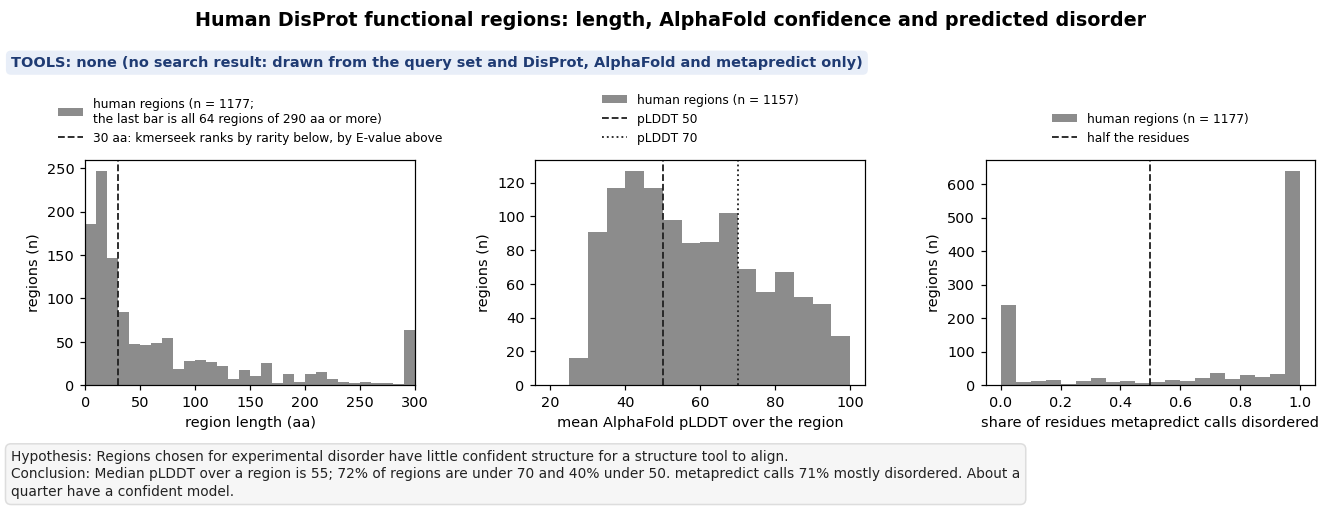

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
GREY, LINE = "#8C8C8C", "#222222"
panels = [
    ("length", "region length (aa)", np.arange(0, 305, 10), [(30, "30 aa: kmerseek ranks by rarity below, by E-value above")]),
    ("mean_plddt_region", "mean AlphaFold pLDDT over the region", np.arange(20, 101, 5), [(50, "pLDDT 50"), (70, "pLDDT 70")]),
    ("disorder_fraction_region", "share of residues metapredict calls disordered", np.linspace(0, 1, 21), [(0.5, "half the residues")]),
]
styles = ["--", ":"]
for ax, (col, xlabel, bins, lines) in zip(axes, panels):
    v = R[col].drop_nulls().to_numpy()
    extra = (f";\nthe last bar is all {int((v >= bins[-2]).sum())} regions of {bins[-2]:g} aa or more"
             if col == "length" else "")
    ax.hist(np.clip(v, bins[0], bins[-1]), bins=bins, color=GREY, label=f"human regions (n = {len(v)}{extra})")
    for (x, lab), ls in zip(lines, styles):
        ax.axvline(x, color=LINE, ls=ls, lw=1.2, label=lab)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("regions (n)")
    ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), frameon=False, fontsize=8)
axes[0].set_xlim(0, 300)
mu.finish_figure(
    fig, FIG / "251_disprot_region_covariates.png", mu.NO_TOOL.replace("Pfam annotations", "DisProt, AlphaFold and metapredict"),
    hypothesis="Regions chosen for experimental disorder have little confident structure for a structure tool to align.",
    conclusion='Median pLDDT over a region is 55; 72% of regions are under 70 and 40% under 50. metapredict calls 71% mostly disordered. About a quarter have a confident model.',
    title="Human DisProt functional regions: length, AlphaFold confidence and predicted disorder",
)

Half the regions are short: the median is 31 aa and 49% are under 30 aa, so they fall on kmerseek's mean-rarity side of the ranking rule. Most have little confident structure: of 1_177 human regions, 1_157 have an AlphaFold model, the median pLDDT over a region is 55, 72% are under 70 and 40% under 50, and metapredict calls 71% of them mostly disordered. The rest are not disordered in the model: about a quarter have a confident structure, which is why section 4 splits the structure tools by pLDDT 70.

**These numbers are from the dry run** (`make run-disprot-local`): two kmerseek arms (hp_pbotc_1st_ed2 k=19 and protein20 k=8, mask on and off) against two targets, yeast and the pooled DisProt set. ProstT5 is absent: its database for these targets takes hours on CPU. The full arm set runs on Sherlock.

## 2. The two splits

The kmerseek arm is picked on one half and every number after this section is reported on
the other. The unit is the HGNC gene group (notebook 244's rule: the parity of the first
byte of the SHA-1 of the group's name), so paralogs never sit on both sides. The second
split holds out whole function terms: the arm is picked on regions of the choose-half
terms, and scored only on terms it never saw.

In [4]:
print(R.group_by("query_half").agg(regions=pl.len(), proteins=pl.col("query_acc").n_unique(),
                                  gene_groups=pl.col("split_unit").n_unique()).sort("query_half"))
print(R.group_by("term_half").agg(regions=pl.len(), terms=pl.col("term_id").n_unique()).sort("term_half"))

shape: (2, 4)
┌────────────┬─────────┬──────────┬─────────────┐
│ query_half ┆ regions ┆ proteins ┆ gene_groups │
│ ---        ┆ ---     ┆ ---      ┆ ---         │
│ str        ┆ u32     ┆ u32      ┆ u32         │
╞════════════╪═════════╪══════════╪═════════════╡
│ choose     ┆ 503     ┆ 206      ┆ 179         │
│ report     ┆ 674     ┆ 270      ┆ 233         │
└────────────┴─────────┴──────────┴─────────────┘
shape: (2, 3)
┌───────────┬─────────┬───────┐
│ term_half ┆ regions ┆ terms │
│ ---       ┆ ---     ┆ ---   │
│ str       ┆ u32     ┆ u32   │
╞═══════════╪═════════╪═══════╡
│ choose    ┆ 321     ┆ 70    │
│ report    ┆ 856     ┆ 60    │
└───────────┴─────────┴───────┘


## 3. Landing, at the same list length for every tool

The landing tables come from `scripts/reduce_disprot_region_landing.py`. A region no tool
reached counts as missed; the fraction is over every human region in the report half.

Every tool here reports deep (E-value up to 1_000, or every kmerseek region), so each human
protein's list holds hundreds of chance hits, and a short chance hit can land inside a
disordered stretch by position alone. So every landed call, from every tool, also goes
through the two controls of section 5, and a landing counts as **passing** when both are
under 5%: the chance that a window of the same length dropped anywhere on the human protein
lands on the region, and the share of length-matched random human queries that rank the
same target protein as high.

In [5]:
LAND = du.load_landing()
HITS = du.load_hits()
RANKS = du.load_ranks()
RHO = du.load_length_rho()
GRID = du.full_grid(R, LAND)
TARGETS = [t for t in du.TARGET_ORDER if t in set(GRID["target"].unique())]
print(f"arms: {GRID['arm'].n_unique()} ({GRID.filter(pl.col('tool') == 'kmerseek')['arm'].n_unique()} kmerseek); targets: {TARGETS}")

# The kmerseek arm per term, picked on the choose half, per target and label rule.
CHOSEN = pl.concat([
    du.choose_arms(GRID, R, t, rule).with_columns(target=pl.lit(t), label_rule=pl.lit(rule))
    for t in TARGETS for rule in du.LABEL_RULES
], how="diagonal_relaxed")
print("\nchosen kmerseek arm, pooled over terms (the arm a term with too few choose-half regions takes):")
print(CHOSEN.filter(~pl.col("own_arm")).group_by("target", "label_rule", "chosen_arm").agg(n_terms=pl.len()).sort("target", "label_rule"))
print(f"terms with their own arm: {CHOSEN.filter('own_arm').height} of {CHOSEN.height} (term, target, rule) cells")

KM = (GRID.filter(pl.col("tool") == "kmerseek")
      .join(CHOSEN, on=["target", "label_rule", "term_id"])
      .filter(pl.col("arm") == pl.col("chosen_arm"))
      .with_columns(tool_label=pl.lit("kmerseek, arm picked per term")))
CMP = GRID.filter(pl.col("tool") != "kmerseek").with_columns(
    tool_label=pl.col("tool").replace_strict(du.COMPARISON_ARMS, default=pl.col("tool")))
BOTH = pl.concat([KM, CMP], how="diagonal_relaxed").join(
    R.select(*KEY, "query_half", "term_half", "term_name", "length", "mean_plddt_region",
             "disorder_fraction_region", "has_model", "protein_length", "gene", "kd_landed"), on=KEY)
REPORT = BOTH.filter(pl.col("query_half") == "report")

# Both controls, on every landed call of every tool (see section 5).
CKEY = [*KEY, "arm", "target", "label_rule"]
LANDED = du.add_placement_p(REPORT.filter("landed").join(R.select(*KEY, "split_unit"), on=KEY))
RQ = du.random_query_p(LANDED, RANKS, R)
LANDED = (LANDED.join(RQ.select(*CKEY, "case_rank", "n_drawn", "random_query_p"), on=CKEY, how="left")
          .with_columns(passes=(pl.col("placement_p") < 0.05) & (pl.col("random_query_p") < 0.05)))
REPORT = REPORT.join(LANDED.select(*CKEY, "placement_p", "case_rank", "n_drawn", "random_query_p", "passes"),
                     on=CKEY, how="left").with_columns(pl.col("passes").fill_null(False))

SUM = du.landing_summary(REPORT, ["target", "label_rule", "tool_label"])
print("\nreport half, per target and label rule:")
print(SUM.with_columns(pct_landed=(pl.col("frac_landed") * 100).round(1),
                       median_iou_landed=pl.col("median_iou_landed").round(2))
         .drop("frac_landed"))
SUM.write_csv(TAB / "251_landing_by_tool.csv")

# The held-out-function split: one pooled arm per target and rule, picked on choose-half
# terms, scored on report-half terms.
CH_T = pl.concat([
    du.choose_arms(GRID, R, t, rule, half_col="term_half", per_term=False)
      .with_columns(target=pl.lit(t), label_rule=pl.lit(rule))
    for t in TARGETS for rule in du.LABEL_RULES
], how="diagonal_relaxed")
KM_T = (GRID.filter(pl.col("tool") == "kmerseek").join(CH_T, on=["target", "label_rule", "term_id"])
        .filter(pl.col("arm") == pl.col("chosen_arm")).with_columns(tool_label=pl.lit("kmerseek, one arm")))
HELD = (pl.concat([KM_T, CMP], how="diagonal_relaxed")
        .join(R.select(*KEY, "term_half"), on=KEY).filter(pl.col("term_half") == "report"))
SUM_T = du.landing_summary(HELD, ["target", "label_rule", "tool_label"])
print("\nheld-out function terms (report-half terms only, arm picked on the other terms):")
print(SUM_T.with_columns(pct_landed=(pl.col("frac_landed") * 100).round(1),
                         median_iou_landed=pl.col("median_iou_landed").round(2)).drop("frac_landed"))
print("\nFigure 2 is drawn from the report-half table, next.")

arms: 10 (4 kmerseek); targets: ['yeast', 'disprot']

chosen kmerseek arm, pooled over terms (the arm a term with too few choose-half regions takes):
shape: (4, 4)
┌─────────┬────────────┬───────────────────────────────────────┬─────────┐
│ target  ┆ label_rule ┆ chosen_arm                            ┆ n_terms │
│ ---     ┆ ---        ┆ ---                                   ┆ ---     │
│ str     ┆ str        ┆ str                                   ┆ u32     │
╞═════════╪════════════╪═══════════════════════════════════════╪═════════╡
│ disprot ┆ any_term   ┆ kmerseek.hp_pbotc_1st_ed2_k19_lcFalse ┆ 109     │
│ disprot ┆ same_term  ┆ kmerseek.hp_pbotc_1st_ed2_k19_lcFalse ┆ 109     │
│ yeast   ┆ any_term   ┆ kmerseek.hp_pbotc_1st_ed2_k19_lcFalse ┆ 109     │
│ yeast   ┆ same_term  ┆ kmerseek.hp_pbotc_1st_ed2_k19_lcFalse ┆ 109     │
└─────────┴────────────┴───────────────────────────────────────┴─────────┘
terms with their own arm: 84 of 520 (term, target, rule) cells



report half, per target and label rule:
shape: (28, 10)
┌─────────┬────────────┬───────────────────────────────┬───────────┬────────────────────┬───────────┬──────────┬───────────────────┬──────────────┬────────────┐
│ target  ┆ label_rule ┆ tool_label                    ┆ n_passing ┆ median_iou_passing ┆ n_regions ┆ n_landed ┆ median_iou_landed ┆ frac_passing ┆ pct_landed │
│ ---     ┆ ---        ┆ ---                           ┆ ---       ┆ ---                ┆ ---       ┆ ---      ┆ ---               ┆ ---          ┆ ---        │
│ str     ┆ str        ┆ str                           ┆ u32       ┆ f64                ┆ u32       ┆ u32      ┆ f64               ┆ f64          ┆ f64        │
╞═════════╪════════════╪═══════════════════════════════╪═══════════╪════════════════════╪═══════════╪══════════╪═══════════════════╪══════════════╪════════════╡
│ disprot ┆ any_term   ┆ Foldseek                      ┆ 5         ┆ 0.92               ┆ 674       ┆ 307      ┆ 0.91              ┆ 0.007

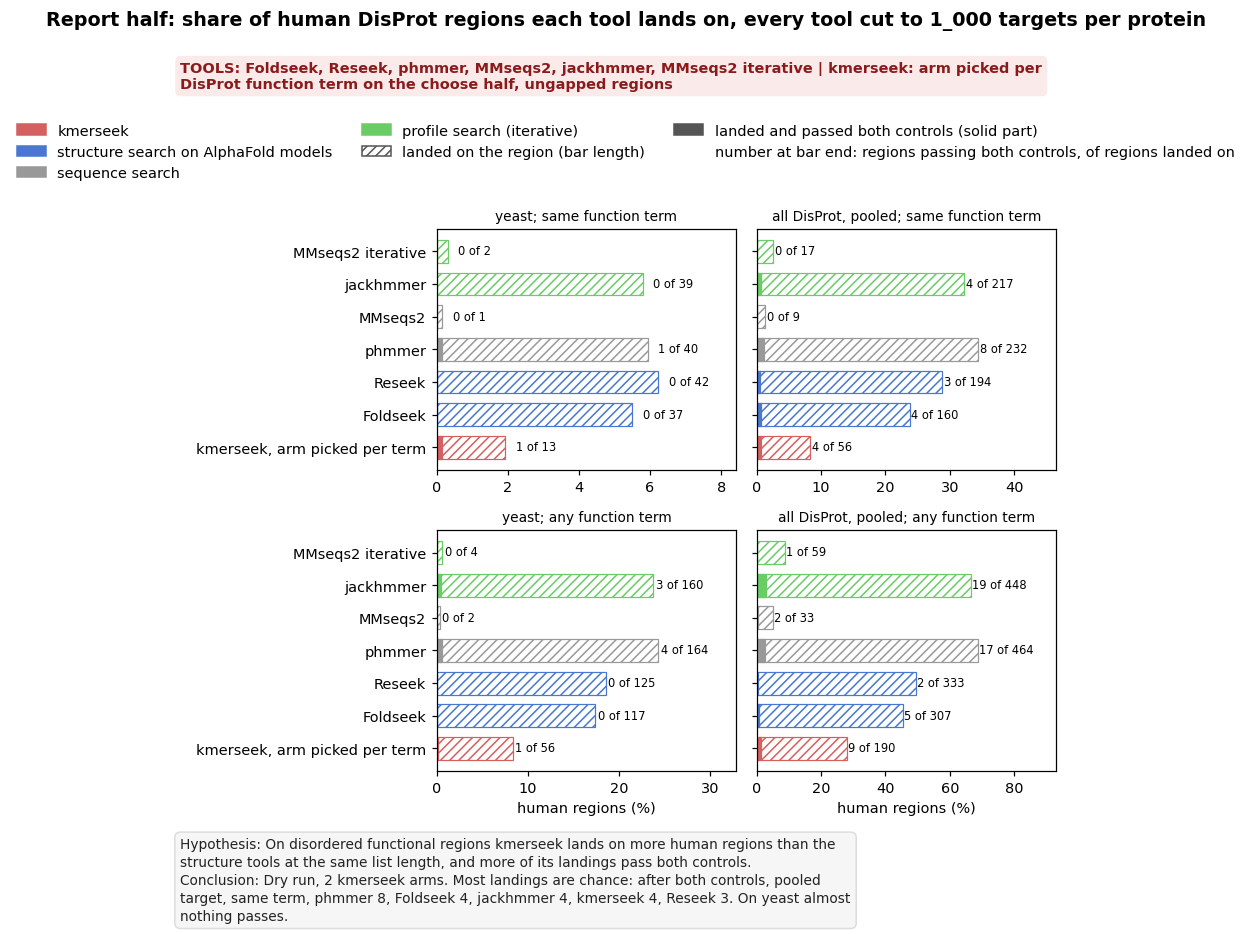

In [6]:
FAM = {"kmerseek, arm picked per term": "kmerseek", "Foldseek": "structure", "Reseek": "structure",
       "ProstT5": "predicted structure", "phmmer": "sequence", "MMseqs2": "sequence",
       "jackhmmer": "profile", "MMseqs2 iterative": "profile"}
FAM_LABEL = {"kmerseek": "kmerseek", "structure": "structure search on AlphaFold models",
             "predicted structure": "structure letters predicted from sequence (ProstT5)",
             "sequence": "sequence search", "profile": "profile search (iterative)"}
order = [t for t in FAM if t in set(SUM["tool_label"])]
rules = list(du.LABEL_RULES)
fig, axes = plt.subplots(len(rules), len(TARGETS), figsize=(3.3 * len(TARGETS) + 1.5, 2.9 * len(rules)),
                         squeeze=False, sharey=True)
for i, rule in enumerate(rules):
    for j, t in enumerate(TARGETS):
        ax = axes[i][j]
        s = {r["tool_label"]: r for r in SUM.filter((pl.col("target") == t) & (pl.col("label_rule") == rule)).iter_rows(named=True)}
        y = np.arange(len(order))
        vals = [100 * s[k]["frac_landed"] if k in s else 0 for k in order]
        passv = [100 * s[k]["frac_passing"] if k in s else 0 for k in order]
        cols = [mu.TOOL_FAMILY_COLORS[FAM[k]] for k in order]
        ax.barh(y, vals, color="white", edgecolor=cols, hatch="////", height=0.7, lw=0.8)
        ax.barh(y, passv, color=cols, edgecolor=cols, height=0.7, lw=0.8)
        for yy, k, v in zip(y, order, vals):
            n = s[k]["n_landed"] if k in s else 0
            n_p = s[k]["n_passing"] if k in s else 0
            ax.text(v + 0.3, yy, f"{n_p} of {n}", va="center", fontsize=7.5)
        ax.set_yticks(y, order)
        ax.invert_yaxis()
        ax.set_xlim(0, max(5, max(vals) * 1.35))
        ax.set_title(f"{du.TARGET_LABEL[t]}; {du.LABEL_RULES[rule]}", fontsize=9)
        if i == len(rules) - 1:
            ax.set_xlabel("human regions (%)")
fams = [f for f in FAM_LABEL if f in {FAM[k] for k in order}]
handles = [plt.Rectangle((0, 0), 1, 1, color=mu.TOOL_FAMILY_COLORS[f]) for f in fams]
labels = [FAM_LABEL[f] for f in fams]
handles += [plt.Rectangle((0, 0), 1, 1, facecolor="white", edgecolor="#555555", hatch="////"),
            plt.Rectangle((0, 0), 1, 1, facecolor="#555555", edgecolor="#555555")]
labels += ["landed on the region (bar length)", "landed and passed both controls (solid part)"]
handles.append(plt.Line2D([], [], ls="", marker=""))
labels.append("number at bar end: regions passing both controls, of regions landed on")
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, 1.0), ncol=3, frameon=False)
LABEL_TO_TOOL = {v: k for k, v in du.COMPARISON_ARMS.items()}
DRAWN = [LABEL_TO_TOOL[k] for k in order if k in LABEL_TO_TOOL]
mu.finish_figure(
    fig, FIG / "251_disprot_landing_by_tool.png",
    mu.tools_text(DRAWN, "kmerseek: arm picked per DisProt function term on the choose half, ungapped regions"),
    hypothesis="On disordered functional regions kmerseek lands on more human regions than the structure tools at the same list length, and more of its landings pass both controls.",
    conclusion='Dry run, 2 kmerseek arms. Most landings are chance: after both controls, pooled target, same term, phmmer 8, Foldseek 4, jackhmmer 4, kmerseek 4, Reseek 3. On yeast almost nothing passes.',
    title="Report half: share of human DisProt regions each tool lands on, every tool cut to 1_000 targets per protein",
    header_y=1.16,
)

Every tool lands on many regions before the controls, and very few after them. On the pooled DisProt target, same function term, report half: phmmer lands on 232 regions and 8 pass both controls; jackhmmer 217 and 4; Reseek 194 and 3; Foldseek 160 and 4; kmerseek 56 and 4; MMseqs2 9 and 0. With any function term the passing counts are phmmer 17, jackhmmer 19, kmerseek 9, Foldseek 5, Reseek 2. On yeast, where only 84 proteins can pass on a label, at most 4 regions pass for any tool.

The median rank of a landed call on the pooled target, same term, is 5 for MMseqs2, 52 for kmerseek and 157 to 279 for the other tools, of up to 1_000; on yeast it is 282 to 467 for every tool but MMseqs2. A call that deep in a list is usually not a relative. With filters opened this far, a landing fraction on its own measures list depth, not transfer.

In [7]:
# Per function term and target, report half, same-term rule.
TERM = du.landing_summary(REPORT.filter(pl.col("label_rule") == "same_term"),
                          ["target", "term_id", "term_name", "tool_label"])
TERM.write_csv(TAB / "251_landing_by_term.csv")
top_terms = R.group_by("term_id").agg(n=pl.len()).sort("n", descending=True).head(8)["term_id"]
print("report half, same function term, the eight most frequent terms:")
print(TERM.filter(pl.col("term_id").is_in(top_terms.implode()))
          .with_columns(pct=(pl.col("frac_landed") * 100).round(1), iou=pl.col("median_iou_landed").round(2))
          .select("target", "term_name", "tool_label", "n_regions", "n_landed", "pct", "iou")
          .sort("target", "term_name", "tool_label"))

report half, same function term, the eight most frequent terms:
shape: (112, 7)
┌─────────┬────────────────────────────────────────┬───────────────────────────────┬───────────┬──────────┬──────┬──────┐
│ target  ┆ term_name                              ┆ tool_label                    ┆ n_regions ┆ n_landed ┆ pct  ┆ iou  │
│ ---     ┆ ---                                    ┆ ---                           ┆ ---       ┆ ---      ┆ ---  ┆ ---  │
│ str     ┆ str                                    ┆ str                           ┆ u32       ┆ u32      ┆ f64  ┆ f64  │
╞═════════╪════════════════════════════════════════╪═══════════════════════════════╪═══════════╪══════════╪══════╪══════╡
│ disprot ┆ DNA binding                            ┆ Foldseek                      ┆ 15        ┆ 1        ┆ 6.7  ┆ 0.59 │
│ disprot ┆ DNA binding                            ┆ MMseqs2                       ┆ 15        ┆ 0        ┆ 0.0  ┆ null │
│ disprot ┆ DNA binding                            ┆ MMseqs2 itera

## 4. What each structure tool did on the regions kmerseek landed on

For every report-half region where the chosen kmerseek arm landed, each structure tool's
best labelled call on that region is put in one of five groups (notebook 244's groups,
plus one for a missing model):

* **no AlphaFold model**: Foldseek and Reseek search AlphaFold models, and the human protein has none
* **no call**: no call carrying a label overlaps the region
* **spills**: calls overlap the region, but under half of every such call lies inside it
* **inside, lower IoU**: a call sits mostly inside the region but overlaps it less well than kmerseek's
* **equal or higher IoU**: the structure tool does at least as well as kmerseek on this region

In [8]:
KM_LAND = REPORT.filter(pl.col("tool_label").str.starts_with("kmerseek") & pl.col("landed")).select(
    "target", "label_rule", *KEY, pl.col("land_iou").alias("km_iou"), pl.col("arm").alias("km_arm"))
ST = (REPORT.filter(pl.col("tool").is_in(list(du.STRUCTURE_ARMS)))
      .join(KM_LAND, on=["target", "label_rule", *KEY])
      .with_columns(category=he.classify_comparison(pl.col("km_iou")))
      .with_columns(category=pl.when(pl.col("tool").is_in(["foldseek", "reseek"]) & ~pl.col("has_model"))
                    .then(pl.lit("no AlphaFold model")).otherwise(pl.col("category")),
                    confident=pl.when(pl.col("mean_plddt_region").is_null()).then(pl.lit("no model"))
                    .when(pl.col("mean_plddt_region") >= 70).then(pl.lit("pLDDT >= 70"))
                    .otherwise(pl.lit("pLDDT < 70"))))
hit_any = HITS.select("arm", "target", *KEY, "n_hits")
ST = ST.join(hit_any.rename({"arm": "tool"}), on=["tool", "target", *KEY], how="left")
CATS = ["no AlphaFold model", "no call", "spills", "inside, lower IoU", "equal or higher IoU"]
tab = (ST.group_by("target", "label_rule", "tool_label", "category").agg(n=pl.len())
         .pivot("category", index=["target", "label_rule", "tool_label"], values="n").fill_null(0))
for c in CATS:
    if c not in tab.columns:
        tab = tab.with_columns(pl.lit(0).alias(c))
print("regions kmerseek landed on (report half), what each structure tool did:")
print(tab.select("target", "label_rule", "tool_label", *CATS).sort("target", "label_rule", "tool_label"))
nc = ST.filter(pl.col("category") == "no call")
print(f"\nof the 'no call' cases, the tool reported something on the region but from a target with no DisProt label: "
      f"{nc.filter(pl.col('n_hits').fill_null(0) > 0).height} of {nc.height}")
print("\nsame split by AlphaFold confidence over the region:")
print(ST.group_by("tool_label", "confident", "category").agg(n=pl.len()).sort("tool_label", "confident", "category"))
ST.write_csv(TAB / "251_structure_tool_per_region.csv")
print("\nFigure 3 is drawn from the first table, next.")

regions kmerseek landed on (report half), what each structure tool did:
shape: (8, 8)
┌─────────┬────────────┬────────────┬────────────────────┬─────────┬────────┬───────────────────┬─────────────────────┐
│ target  ┆ label_rule ┆ tool_label ┆ no AlphaFold model ┆ no call ┆ spills ┆ inside, lower IoU ┆ equal or higher IoU │
│ ---     ┆ ---        ┆ ---        ┆ ---                ┆ ---     ┆ ---    ┆ ---               ┆ ---                 │
│ str     ┆ str        ┆ str        ┆ i32                ┆ u32     ┆ u32    ┆ u32               ┆ u32                 │
╞═════════╪════════════╪════════════╪════════════════════╪═════════╪════════╪═══════════════════╪═════════════════════╡
│ disprot ┆ any_term   ┆ Foldseek   ┆ 0                  ┆ 0       ┆ 19     ┆ 30                ┆ 141                 │
│ disprot ┆ any_term   ┆ Reseek     ┆ 0                  ┆ 0       ┆ 14     ┆ 26                ┆ 150                 │
│ disprot ┆ same_term  ┆ Foldseek   ┆ 0                  ┆ 4       ┆ 6    

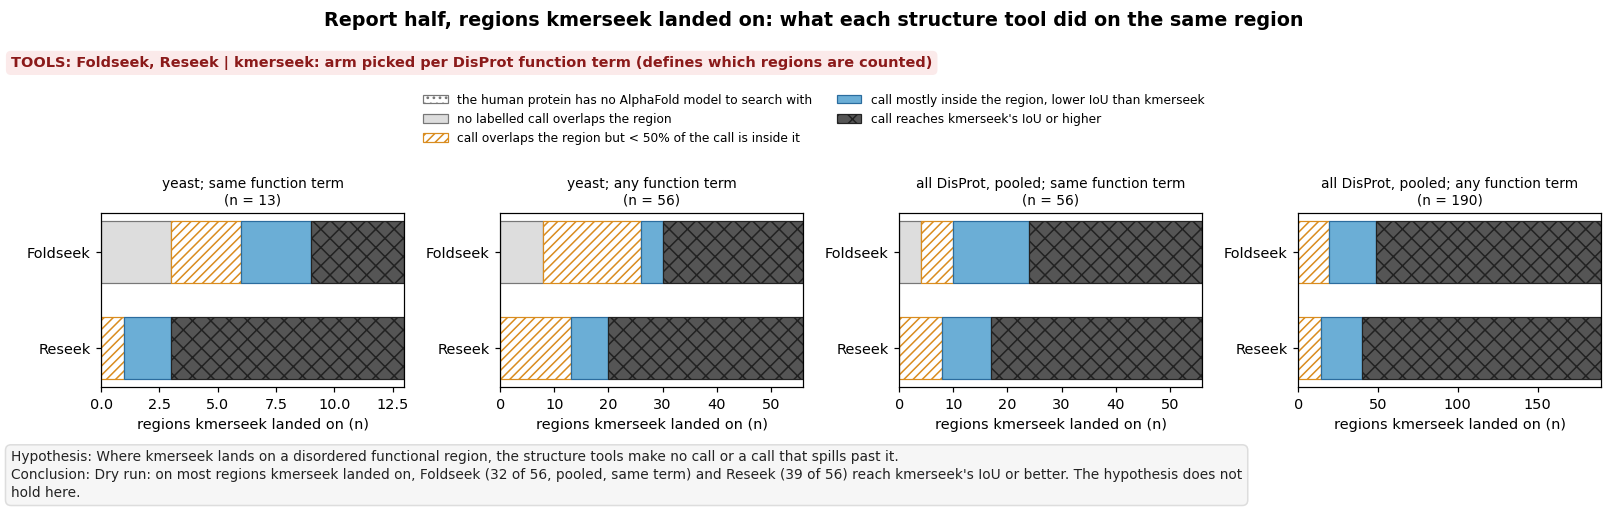

In [9]:
STYLE = {**he.CATEGORY_STYLE,
         "no call": dict(facecolor="#DDDDDD", edgecolor="#777777", hatch=""),
         "no AlphaFold model": dict(facecolor="white", edgecolor="#777777", hatch="...")}
LABEL = {**he.CATEGORY_LABEL,
         "no call": "no labelled call overlaps the region",
         "no AlphaFold model": "the human protein has no AlphaFold model to search with"}
LABEL["equal or higher IoU"] = "call reaches kmerseek's IoU or higher"
LABEL["inside, lower IoU"] = "call mostly inside the region, lower IoU than kmerseek"
LABEL["spills"] = "call overlaps the region but < 50% of the call is inside it"
rows = ST.group_by("target", "label_rule", "tool_label", "category").agg(n=pl.len())
panels = [(t, r) for t in TARGETS for r in du.LABEL_RULES]
fig, axes = plt.subplots(1, len(panels), figsize=(3.4 * len(panels) + 1, 2.6), squeeze=False)
for ax, (t, rule) in zip(axes[0], panels):
    sub = rows.filter((pl.col("target") == t) & (pl.col("label_rule") == rule))
    tools = [l for l in du.STRUCTURE_ARMS.values() if l in set(ST["tool_label"])]
    total = KM_LAND.filter((pl.col("target") == t) & (pl.col("label_rule") == rule)).height
    for yy, tl in enumerate(tools):
        left = 0
        for c in CATS:
            n = sub.filter((pl.col("tool_label") == tl) & (pl.col("category") == c))["n"].sum()
            if n:
                ax.barh(yy, n, left=left, height=0.65, **STYLE[c], lw=0.8)
                left += n
    ax.set_yticks(range(len(tools)), tools)
    ax.invert_yaxis()
    ax.set_xlim(0, max(1, total))
    ax.set_xlabel("regions kmerseek landed on (n)")
    ax.set_title(f"{du.TARGET_LABEL[t]}; {du.LABEL_RULES[rule]}\n(n = {total})", fontsize=9)
handles = [plt.Rectangle((0, 0), 1, 1, **STYLE[c], lw=0.8) for c in CATS]
fig.legend(handles, [LABEL[c] for c in CATS], loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=False, fontsize=8)
mu.finish_figure(
    fig, FIG / "251_disprot_structure_tools_per_region.png",
    mu.tools_text(sorted(ST["tool"].unique()), "kmerseek: arm picked per DisProt function term (defines which regions are counted)"),
    hypothesis="Where kmerseek lands on a disordered functional region, the structure tools make no call or a call that spills past it.",
    conclusion="Dry run: on most regions kmerseek landed on, Foldseek (32 of 56, pooled, same term) and Reseek (39 of 56) reach kmerseek's IoU or better. The hypothesis does not hold here.",
    title="Report half, regions kmerseek landed on: what each structure tool did on the same region",
    header_y=1.32,
)

The regions kmerseek lands on are mostly ones the structure tools also land on, as well or better. Pooled target, same function term, 56 regions: Foldseek equal or better on 32, mostly inside but with lower IoU on 14, spilling on 6, no labelled call on 4; Reseek equal or better on 39, lower IoU on 9, spilling on 8. 50 of the 56 regions have pLDDT under 70, and on those 50 Foldseek still matches or beats kmerseek on 27 and Reseek on 33, so a low-confidence model did not stop them placing the label. Two arms is a small sample of kmerseek; the full arm set may change this.

## 5. Controls

Four checks, each asking whether a landed call could have landed without homology.

1. **Kyte-Doolittle scan** (notebook 231): a sliding window of hydrophobicity that knows
   nothing about other proteins, scored against the same regions by position.
2. **Placement control**: for each landed kmerseek call, the chance that a window of the
   same length dropped anywhere on the human protein lands on the region by the same rule.
   A call only counts as evidence when this chance is under 5%.
3. **Length-matched random queries**: for each landed case, other human query proteins of
   the same length (within 20%, a different HGNC gene group) are asked whether they put the
   same target protein at the same rank or better. p = (1 + queries that do) / (1 + queries asked).
4. **Is a ranking score region length in disguise?** Spearman correlation of each score
   with call length, over every call in the lists.

In [10]:
kd = R.filter(pl.col("query_half") == "report")
print(f"1. Kyte-Doolittle scan lands on {kd['kd_landed'].sum()} of {kd.height} report-half regions")

print("\n2-3. every tool's landed calls (report half) and how many pass each control:")
CTRL = (LANDED.group_by("target", "label_rule", "tool_label").agg(
    landed=pl.len(),
    median_rank=pl.col("case_rank").median(),
    placement_p_under_05=(pl.col("placement_p") < 0.05).sum(),
    random_query_p_under_05=(pl.col("random_query_p") < 0.05).sum(),
    both=pl.col("passes").sum(),
    also_kd_landed=pl.col("kd_landed").sum(),
    median_random_queries_drawn=pl.col("n_drawn").median(),
).sort("target", "label_rule", "tool_label"))
print(CTRL)
CTRL.write_csv(TAB / "251_controls_by_tool.csv")
KMC = LANDED.filter(pl.col("tool_label").str.starts_with("kmerseek"))

print("\n4. Spearman rho of each ranking score with call length:")
RHO_T = (RHO.with_columns(tool_label=pl.col("arm").map_elements(du.arm_label, return_dtype=pl.String))
            .group_by("tool", "rank_by").agg(n_arms=pl.len(), median_rho=pl.col("spearman_rho").median(),
                                             min_rho=pl.col("spearman_rho").min(), max_rho=pl.col("spearman_rho").max(),
                                             calls=pl.col("n_calls").sum())
            .sort("tool", "rank_by"))
print(RHO_T)
print("\nFigure 4 is drawn from these tables, next.")

1. Kyte-Doolittle scan lands on 0 of 674 report-half regions

2-3. every tool's landed calls (report half) and how many pass each control:
shape: (28, 10)
┌─────────┬────────────┬───────────────────────────────┬────────┬─────────────┬──────────────────────┬─────────────────────────┬──────┬────────────────┬─────────────────────────────┐
│ target  ┆ label_rule ┆ tool_label                    ┆ landed ┆ median_rank ┆ placement_p_under_05 ┆ random_query_p_under_05 ┆ both ┆ also_kd_landed ┆ median_random_queries_drawn │
│ ---     ┆ ---        ┆ ---                           ┆ ---    ┆ ---         ┆ ---                  ┆ ---                     ┆ ---  ┆ ---            ┆ ---                         │
│ str     ┆ str        ┆ str                           ┆ u32    ┆ f64         ┆ u32                  ┆ u32                     ┆ u32  ┆ u32            ┆ f64                         │
╞═════════╪════════════╪═══════════════════════════════╪════════╪═════════════╪══════════════════════╪═══════════

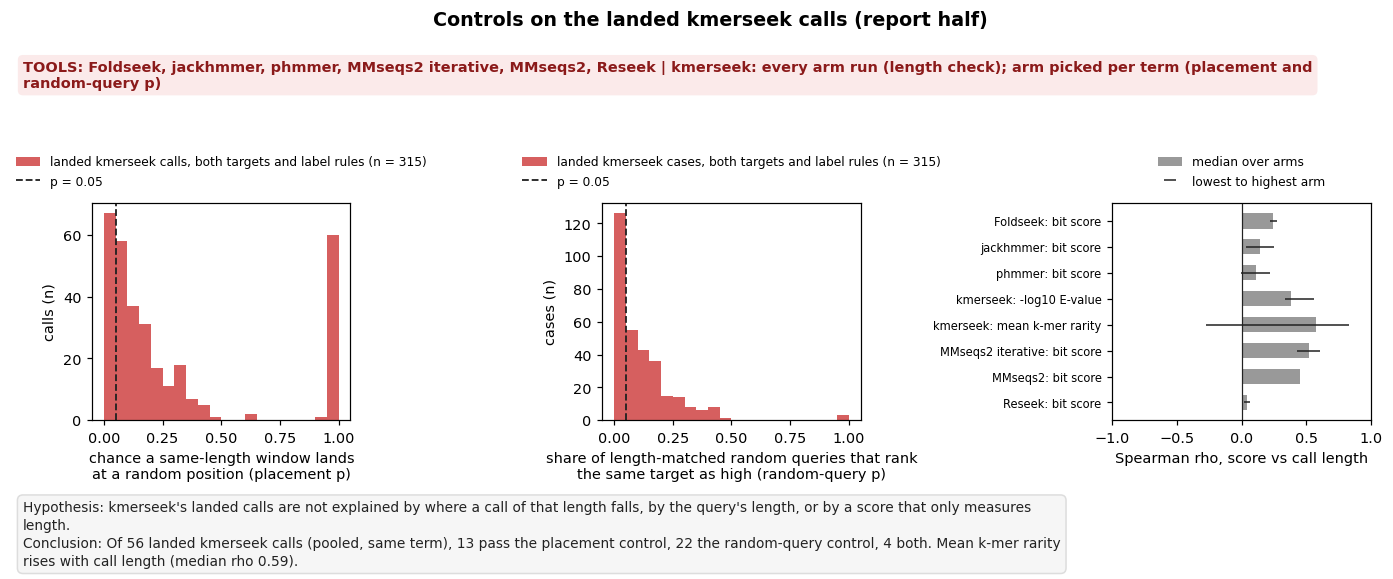

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.3))
ax = axes[0]
v = KMC["placement_p"].drop_nulls().to_numpy()
ax.hist(v, bins=np.linspace(0, 1, 21), color="#D65F5F", label=f"landed kmerseek calls, both targets and label rules (n = {len(v)})")
ax.axvline(0.05, color="#222222", ls="--", lw=1.2, label="p = 0.05")
ax.set_xlabel("chance a same-length window lands\nat a random position (placement p)")
ax.set_ylabel("calls (n)")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), frameon=False, fontsize=8)
ax = axes[1]
v = KMC["random_query_p"].drop_nulls().to_numpy()
ax.hist(v, bins=np.linspace(0, 1, 21), color="#D65F5F", label=f"landed kmerseek cases, both targets and label rules (n = {len(v)})")
ax.axvline(0.05, color="#222222", ls="--", lw=1.2, label="p = 0.05")
ax.set_xlabel("share of length-matched random queries that rank\nthe same target as high (random-query p)")
ax.set_ylabel("cases (n)")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), frameon=False, fontsize=8)
ax = axes[2]
SCORE_NAME = {"mean_idf": "mean k-mer rarity", "evalue_score": "-log10 E-value", "score": "bit score"}
lab = [f"{du.COMPARISON_ARMS.get(r['tool'], r['tool'])}: {SCORE_NAME.get(r['rank_by'], r['rank_by'])}"
       for r in RHO_T.iter_rows(named=True)]
ax.barh(range(RHO_T.height), RHO_T["median_rho"].to_numpy(), color="#999999", height=0.6, label="median over arms")
ax.errorbar(RHO_T["median_rho"].to_numpy(), range(RHO_T.height),
            xerr=[RHO_T["median_rho"] - RHO_T["min_rho"], RHO_T["max_rho"] - RHO_T["median_rho"]],
            fmt="none", ecolor="#222222", lw=1, label="lowest to highest arm")
ax.axvline(0, color="#222222", lw=0.8)
ax.set_yticks(range(RHO_T.height), lab, fontsize=7.5)
ax.invert_yaxis()
ax.set_xlim(-1, 1)
ax.set_xlabel("Spearman rho, score vs call length")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), frameon=False, fontsize=8)
mu.finish_figure(
    fig, FIG / "251_disprot_controls.png",
    mu.tools_text(sorted(t for t in RHO_T["tool"].unique() if t != "kmerseek"),
                  "kmerseek: every arm run (length check); arm picked per term (placement and random-query p)"),
    hypothesis="kmerseek's landed calls are not explained by where a call of that length falls, by the query's length, or by a score that only measures length.",
    conclusion='Of 56 landed kmerseek calls (pooled, same term), 13 pass the placement control, 22 the random-query control, 4 both. Mean k-mer rarity rises with call length (median rho 0.59).',
    title="Controls on the landed kmerseek calls (report half)",
    header_y=1.12,
)

The Kyte-Doolittle scan lands on none of the 674 report-half regions, so hydrophobicity alone does not place these labels. The placement control removes most landings for every tool: on the pooled target, 13 of kmerseek's 56 same-term landings and 37 of Foldseek's 160 fall below 5%. The random-query control draws a median of 56 to 81 length-matched queries per case, so its smallest possible p is about 0.012 to 0.018. Mean k-mer rarity, the score kmerseek ranks short regions by, is not independent of length on these arms: its median Spearman rho with call length is 0.59, up to 0.83. The E-value score is 0.41; the aligners' bit scores run from 0.07 (Reseek) to 0.61 (MMseqs2 iterative).

## 6. Top cases, residue by residue

Landed kmerseek cases from the report half that pass both the placement control and the
random-query control (p < 0.05 each), ordered by how badly the structure tools did on the
same region, then by IoU. kmerseek regions are gapless, so residue *i* of the human
stretch faces residue *i* of the target stretch. Each case prints the residues with a `|`
under every identical pair, then the same stretch as hp_pbotc_1st_ed2 classes (H =
ACFILMPVWY, P = DEGHKNQRST) with its own match line. Coordinates are 1-based and inclusive.

In [12]:
worst = {"no AlphaFold model": 4, "no call": 4, "spills": 3, "inside, lower IoU": 2, "equal or higher IoU": 0}
score = (ST.with_columns(w=pl.col("category").replace_strict(worst, default=0))
           .sort("tool_label")
           .group_by("target", "label_rule", *KEY).agg(
               structure_badness=pl.col("w").sum(),
               categories=pl.concat_str("tool_label", pl.lit(": "), "category").str.join("; ")))
TOP = (KMC.filter((pl.col("placement_p") < 0.05) & (pl.col("random_query_p") < 0.05))
          .join(score, on=["target", "label_rule", *KEY], how="left")
          .sort(["label_rule", "structure_badness", "land_iou"], descending=[True, True, True])
          .unique([*KEY], keep="first", maintain_order=True).head(10))
print(f"{TOP.height} cases pass both controls")
hseq = du.human_sequences(set(TOP["query_acc"]))
for r in TOP.iter_rows(named=True):
    tseq = du.target_sequences(r["target"], {r["land_target_acc"]}).get(r["land_target_acc"])
    print("=" * 100)
    print(f"human {r['gene']} ({r['query_acc']}) {r['term_name']} [{r['term_id']}], region "
          f"{r['true_start'] + 1}-{r['true_end']} ({r['length']} aa), pLDDT "
          f"{'none' if r['mean_plddt_region'] is None else round(r['mean_plddt_region'], 1)}, "
          f"disordered fraction {'none' if r['disorder_fraction_region'] is None else round(r['disorder_fraction_region'], 2)}")
    print(f"target {du.TARGET_LABEL[r['target']]} {r['land_target_acc']}, its DisProt region "
          f"{r['land_t_feat_start'] + 1}-{r['land_t_feat_end']}; label rule: {du.LABEL_RULES[r['label_rule']]}")
    print(f"kmerseek {he.arm_short(r['arm'])}, ranked by {r['rank_by']}: IoU {r['land_iou']:.2f}, "
          f"rank {r['case_rank']}, placement p {r['placement_p']:.3f}, random-query p {r['random_query_p']:.3f} "
          f"({r['n_drawn']} queries)")
    print(f"structure tools: {r['categories']}")
    if tseq is None:
        print("(target sequence not found)")
        continue
    print(he.format_alignment(f"human {r['gene']}", f"{r['target']} {r['land_target_acc']}", hseq[r["query_acc"]], tseq,
                              r["land_qstart"], r["land_qend"], r["land_tstart"], r["land_tend"]))

9 cases pass both controls
human AGER (Q15109) molecular adaptor activity [GO:0060090], region 364-404 (41 aa), pLDDT 61.5, disordered fraction 1.0
target yeast Q05471, its DisProt region 599-627; label rule: same function term
kmerseek hp_pbotc_1st_ed2 k19 (mask off), ranked by evalue_score: IoU 0.98, rank 112, placement p 0.027, random-query p 0.038 (104 queries)
structure tools: Foldseek: no call; Reseek: inside, lower IoU
8 of 40 residues identical (20%); query 364-403, target 594-633
human AGER          364 QRRQRRGEERKAPENQEEEEERAELNQSEEPEAGESSTGG 403
                                        ||      |  ||      ||  |
yeast Q05471        594 DDKTPSVGLSALFGKGEESDGDLDLDDSEDFTVNSSSVEG 633

hp_pbotc_1st_ed2 classes (H = ACFILMPVWY, P = DEGHKNQRST); longest run of identical classes: 26 positions, query 375-400
human AGER          364 PPPPPPPPPPPHHPPPPPPPPPHPHPPPPPHPHPPPPPPP
                        |||| | | | |||||||||||||||||||||||||| ||
yeast Q05471        594 PPPPHPHPHPHHHPPPPPPPPPHPHPP

## What the dry run says

* The pipeline runs end to end on one QfO species (yeast) and on the pooled DisProt target, with every comparison tool except ProstT5's search step.
* At the same list length and with filters opened, raw landing counts are mostly chance for every tool. The comparison has to be made on landings that pass both controls, and there are few: at most 8 per tool on the pooled target and at most 4 on yeast.
* On those, kmerseek's two arms tie Foldseek and jackhmmer on the same-term rule (4 each) and sit behind phmmer (8). With any function term kmerseek (9) is ahead of the structure tools (Foldseek 5, Reseek 2) and behind jackhmmer (19) and phmmer (17).
* The premise that structure tools have nothing to align holds for most regions but not all: Foldseek and Reseek matched or beat kmerseek's placement on most of the regions kmerseek landed on.
* The top kmerseek cases share 7-20% of residues but runs of 20-26 identical hp_pbotc_1st_ed2 classes, often in stretches rich in charged residues. The controls pass narrowly (p 0.009 to 0.046), so each needs a look before it is called a transfer.
* Mean k-mer rarity is correlated with call length on these arms, so the under-30 aa ranking rule should be checked on the full arm set before it is trusted.